# **Lista de Atividades**
**Autor:** Pedro Melo
**Disciplina:** Aprendizado Profundo
**Professor:** Tiago Maritan

### Importando bibliotecas

## Questão 3

Implemente e treine uma Rede Neural Convolucional (CNN) para resolver o problema de classificação de objetos em imagens utilizando a base de dados CIFAR-10, disponível em: https://www.cs.toronto.edu/~kriz/cifar.html. Apresente a curva do erro médio ao longo do treinamento, bem como a matriz de confusão do modelo avaliado sobre o conjunto de testes.


Sobre o CIFAR-10:

- 60 mil imagens divididas entre 10 classes (Cada classe com 6 mil imagens -> bom balanceamento)
- Imagens são 32 x 32 e coloridas (x3)

In [34]:
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import glob
import random
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.applications import ResNet50
from pathlib import Path
import os
from sklearn.metrics import confusion_matrix
import warnings
import json
import tensorflow as tf
from keras.callbacks import EarlyStopping
import pprint
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### Resolução da questão a partir de classe com funções para construir, treinar e avaliar o modelo

In [ ]:
class CifarCNN:

    def __init__(self):

        warnings.filterwarnings("ignore")

        self.labels = {
            0: "Airplane",
            1: "Car",
            2: "Bird",
            3: "Cat",
            4: "Deer",
            5: "Dog",
            6: "Frog",
            7: "Horse",
            8: "Sheep",
            9: "Truck"
        }

        self.img_shape = (32, 32, 3) # rgb

    
    def load_transform_data(self):
        
        try:
            (X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
            train_size = int(X_train_full.shape[0] * 0.8)

            print(f"Testando formato dos dados...")
            try:
                teste_formato = y_train_full.shape[1]
                teste_formato_2 = X_train_full.shape[3]
                print("Formatos das labels OK. Prosseguindo...")
            except:
                y_train = y_train.resize(y_train.shape[0], 1)
                y_test = y_test.resize(y_test.shape[0], 1)
                X_train_full = X_train_full.resize(X_train_full.shape[0], *self.img_shape)
                X_test_full = X_test_full.resize(X_test_full.shape[0], *self.img_shape)

            X_train, X_valid = X_train_full[:train_size], X_train_full[train_size:]
            
            if X_train[0].max() > 1:
                X_train = X_train / 255.0
                X_valid = X_valid / 255.0
                X_test = X_test / 255.0

            y_train, y_valid = y_train_full[:train_size], y_train_full[train_size:]

        
        except Exception as error:
            raise Exception(f"Não foi possível importar e tratar o conjunto de dados CIFAR-10: {error}") from error

        print("-" * 50)
        print("Resumo da base de dados: CIFAR-10")
        print("-" * 50)
        print(f"Formato do conjunto de treino: {X_train.shape}")
        print(f"Formato do conjunto de teste: {X_test.shape}")
        print(f"Formato do conjunto de validação: {X_valid.shape}")
        print(f"Formato do target: {y_train.shape}")
        print("-" * 50)

        self.X_train = X_train
        self.y_train = y_train

        self.X_test = X_test
        self.y_test = y_test

        self.X_valid = X_valid
        self.y_valid = y_valid

        return X_train, y_train, X_test, y_test, X_valid, y_valid
    

    def get_imgs_examples(self):

        imgs = []
        true_label = []

        for classe in range(10):
            
            idx_classe = np.where(self.y_train == classe)[0]
            idx_chosen = np.random.choice(idx_classe)

            imgs.append(self.X_train[idx_chosen])
            true_label.append(classe)

        imagens = np.array(imgs)

        plt.figure(figsize=(18, 8))

        for i in range(10):
            plt.subplot(2, 5, i+1)
            plt.imshow(imagens[i])
            plt.title(f"{self.labels[i]}")


        print("Exemplos de imagens do dataset CIFAR-10")
        plt.tight_layout()
        plt.show()


        return None
    

    def build_simple_model(self, num_conv_pooling:int=6, 
                           num_filters:int=16,
                           kernel_size:tuple=(3, 3),
                           pool_size:tuple=(2,2), 
                           conv_activation="relu",
                           dense_layers:int=4,
                           dense_neurons:int=32
                           ):

        try:
            model = Sequential([
                            Conv2D(num_filters, kernel_size, 
                             activation=conv_activation,
                             padding="same",
                             input_shape=self.img_shape)
                        ])
            
            for i in range(1, num_conv_pooling + 1):

                if i > 1:
                    model.add(Conv2D(num_filters, kernel_size, 
                                     padding="same",
                                    activation=conv_activation))
                
                model.add(Conv2D(num_filters, kernel_size,
                                 padding="same",
                                 activation=conv_activation))
                
                model.add(MaxPooling2D(pool_size))
            
            model.add(Flatten())
            for i in range(1, dense_layers + 1):
                model.add(Dense(dense_neurons // i, activation="relu"))
            
            model.add(Dense(10, activation="softmax"))

        except Exception as error:
            raise Exception(f"Não foi possível construir a CNN: {error}")
        
        return model
    

    def train_model(
            self,
            model_name,
            model: keras.Model,
            validation_set,
            batch_size, epochs,
            optimizer="adam"):

        try:
            model.compile(optimizer=optimizer, 
                               loss="sparse_categorical_crossentropy",
                               metrics=["accuracy"])
            
            history = model.fit(
                self.X_train, self.y_train,
                batch_size=batch_size, epochs=epochs,
                validation_data=validation_set,
                verbose=False
                )

            pd.DataFrame(history.history).plot()
            plt.grid(True)
            plt.gca().set_ylim(0, 1)
            plt.title(f"Curva de aprendizagem: {model_name}")
            plt.show()
            
            self.batch_size = batch_size
            self.nome_rede = model_name

        except Exception as error:
            raise Exception(f"Não foi possível realizar o treinamento do modelo: {error}") from error
        
        return model
        
    
    def evaluate_model(
            self,
            trained_model):

        try:
            
            accuracy = trained_model.evaluate(self.X_test, self.y_test, batch_size=self.batch_size)[1]
            probas = trained_model.predict(self.X_test, batch_size=self.batch_size, verbose=False)
            predictions = np.argmax(probas, axis=1)
            conf_matrix = confusion_matrix(self.y_test, predictions)
            
            print(f"Acurácia do modelo {self.nome_rede}: {accuracy}")

            print(f"Matriz de Confusão do Modelo: ")
            print(conf_matrix)

        except Exception as error:

            raise Exception(f"Erro ao avaliar modelo: {error}") from error
        
        return accuracy


    def test_prediction(self, model):

        imgs = []
        true_label = []
        y_test = self.y_test.flatten()

        for classe in range(10):
            
            idx_classe = np.where(y_test == classe)[0]
            idx_chosen = np.random.choice(idx_classe)

            imgs.append(self.X_test[idx_chosen])
            true_label.append(classe)

        imagens = np.array(imgs)

        preds = model.predict(imagens, verbose=0)
        class_preds = np.argmax(preds, axis=1)

        plt.figure(figsize=(18, 8))

        for i in range(10):
            plt.subplot(2, 5, i+1)
            plt.imshow(imagens[i])
            plt.axis("off")

            plt.title(f"Classe real: {self.labels[true_label[i]]}. Clase Predita: {self.labels[class_preds[i]]}")

        plt.tight_layout()
        plt.show()

        return None
    
    
    def chose_best_model(self, results_dict: dict[keras.Model]):

        try:
            results_sorted = dict(sorted(results_dict.items(), key=lambda x: x[1], reverse=True))
            resultados_consolidados = {}
            print(results_sorted)
            for rede, res in results_sorted.items():

                items = rede.split("_")
                conv_pool, batch, epochs = items[1], items[2], items[3]
                
                print(f"Resultados da aplicação da Rede {rede}")
                print(f"Camadas Conv-Pool: {conv_pool}")
                print(f"Tamanho do Batch: {batch}")
                print(f"Nº de épocas: {epochs}")
                print(f"Acurácia: {round(res, 2)}")
                print("-"*50)

                resultados_consolidados[rede] = {
                    "conv_pool_layers": conv_pool,
                    "batch_size": batch,
                    "epochs": epochs,
                    "accuracy": res
                }


            with open("results.json", "w") as file:
                
                json.dump(resultados_consolidados, file)

            best_model = list(results_sorted.keys())[0]
            print(f"Números do melhor modelo: {resultados_consolidados[best_model]}")

        except Exception as error:
            raise Exception(f"Não foi possível avaliar o melhor modelo: {error}") from error
        
        return best_model
    
    
    def tune_resnet(self, dense_layers:int, 
                    dense_neurons:int=128):

        try:

            nn = Sequential()
            resnet = ResNet50(include_top=False, 
                              input_shape=self.img_shape,
                              pooling="max", classes=len(self.labels.keys()))
            for layer in resnet.layers:
                layer.trainable = False

            nn.add(resnet)
            nn.add(Flatten())
            for i in range(1, dense_layers+1):
                nn.add(Dense(dense_neurons//i))
            nn.add(Dense(10, activation="softmax"))

        except Exception as error:
            raise Exception(f"Não foi possível construir a ResNet: {error}") from error
        
        return nn

## Rotina de Criação e Avaliação das Redes

Testando formato dos dados...
Formatos das labels OK. Prosseguindo...
--------------------------------------------------
Resumo da base de dados: CIFAR-10
--------------------------------------------------
Formato do conjunto de treino: (40000, 32, 32, 3)
Formato do conjunto de teste: (10000, 32, 32, 3)
Formato do conjunto de validação: (10000, 32, 32, 3)
Formato do target: (40000, 1)
--------------------------------------------------
Exemplos de imagens do dataset CIFAR-10


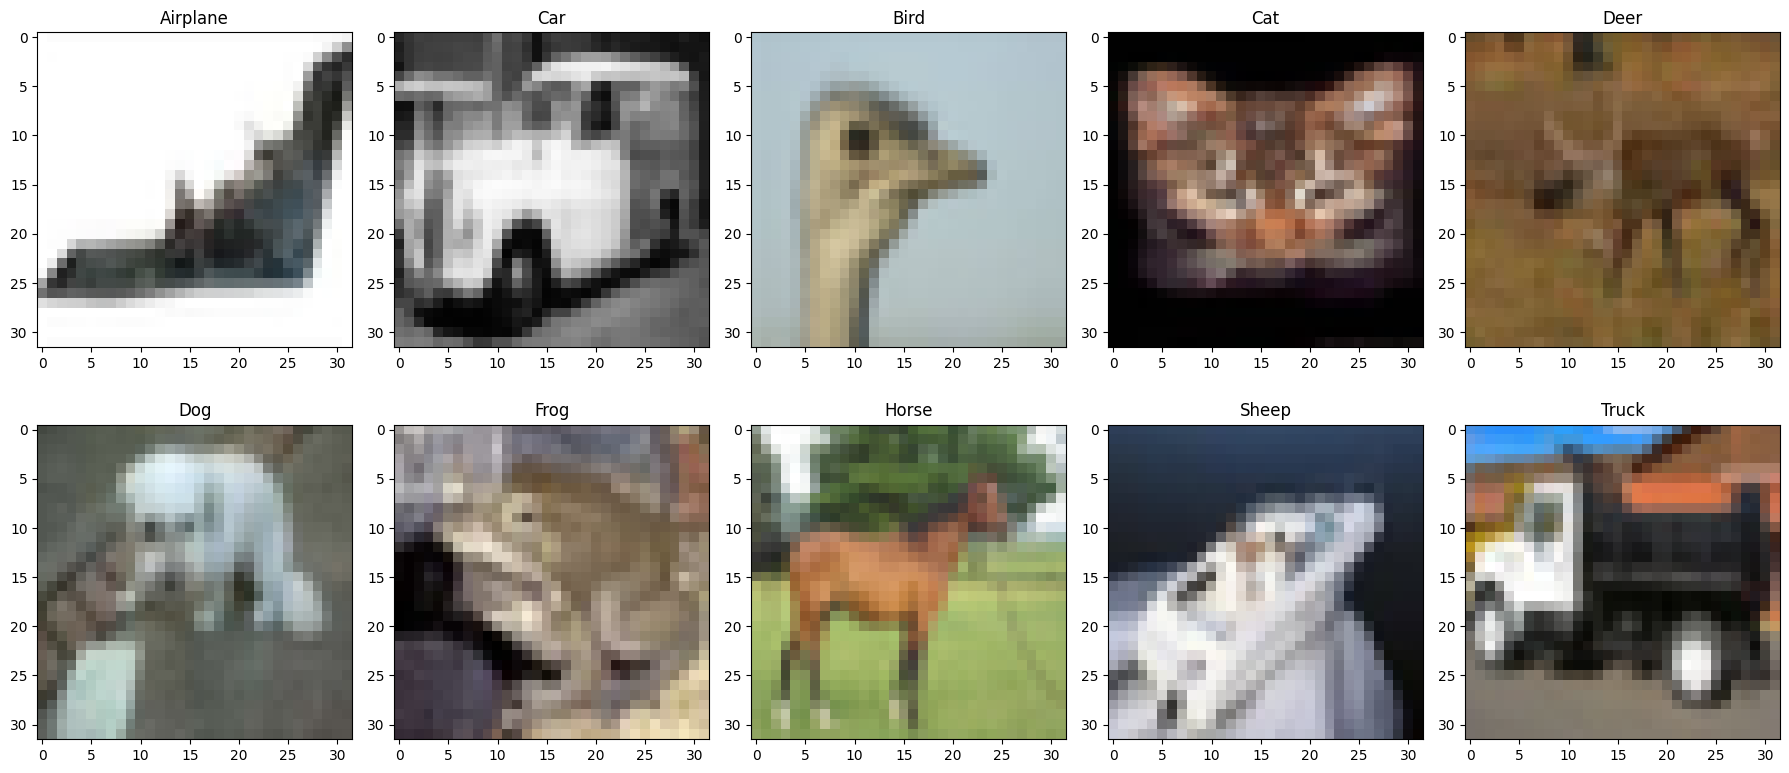

In [36]:

from pprint import pprint
cifar_cnn = CifarCNN()
X_train, y_train, X_test, y_test, X_valid, y_valid = cifar_cnn.load_transform_data()
validation_set = (X_valid, y_valid)
cifar_cnn.get_imgs_examples()

# testing_models = {
#     "CNN_1": cifar_cnn.build_simple_model(num_conv_pooling=1, num_filters=8,
#                                           dense_layers=2, dense_neurons=8),
#     "CNN_2": cifar_cnn.build_simple_model(num_conv_pooling=2, num_filters=16,
#                                           dense_layers=4, dense_neurons=32),
#     "CNN_3": cifar_cnn.build_simple_model(num_conv_pooling=3, num_filters=8,
#                                           dense_layers=6, dense_neurons=64),

#     "RES_2": cifar_cnn.tune_resnet(2, dense_neurons=64),
#     "RES_4": cifar_cnn.tune_resnet(4),
#     "RES_8": cifar_cnn.tune_resnet(8, dense_neurons=256),
# }

# full_epoch_size = X_train.shape[0]

# batchs_epochs_combination = {
#     full_epoch_size: 100,
#     full_epoch_size//2: 80,
#     full_epoch_size//4: 60,
#     full_epoch_size//8: 50,
#     full_epoch_size//16: 40,
#     full_epoch_size//32: 30,
#     full_epoch_size//64: 20,
# }

# results_dict = {}

# for name, model in testing_models.items():

#     for batch_size, epochs in batchs_epochs_combination.items():
        
#         model_name = f"{name}_{batch_size}_{epochs}"

#         trained_model = cifar_cnn.train_model(model_name, model,
#                               validation_set, batch_size, epochs)
        
#         model_result = cifar_cnn.evaluate_model(trained_model)

#         results_dict[model_name] = model_result

In [7]:
best_model = cifar_cnn.chose_best_model(
    results_dict
)

NameError: name 'results_dict' is not defined

## Tentando melhorar acurácia e generalização com 3 coisas:

- Dropout
- Batch Normalization
- Data Augmentation

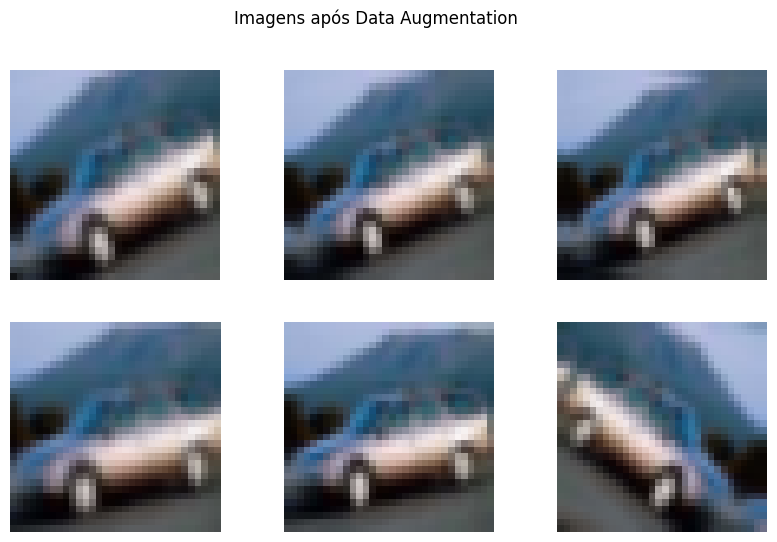

In [40]:
# best_model: conv-pool 2, batch size 625 e 20 epochs

from keras.layers import (
    RandomFlip, RandomRotation,
    RandomZoom, BatchNormalization, 
    Dropout
)

data_aug_layers = Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1)
    ]
)

# exemplo de imagens rotacionadas
plt.figure(figsize=(10,6))
image = X_train[4]
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    aug_img = data_aug_layers(np.expand_dims(image, 0), training=True)
    plt.imshow(aug_img[0])
    plt.axis("off")

plt.suptitle("Imagens após Data Augmentation")
plt.show()

In [53]:
# melhorando funcao de construcao da rede

    
def build_new_cnn(num_conv_pool:int=2, 
                  num_filters:int=32,
                  kernel_size:tuple=(3,3),
                  pool_size:tuple=(2,2),
                  conv_activation:str="relu",
                  dense_layers:int=2,
                  dense_neurons:int=64,
                  dropout_conv:float=.25,
                  dropout_dense=.5):
    
    try:

        model = Sequential([
            data_aug_layers,
            Conv2D(filters=num_filters,
                   kernel_size=kernel_size,
                   input_shape=(32, 32, 3)),
            BatchNormalization()
        ])

        for i in range(1, num_conv_pool + 1):

            if i > 1:
                model.add(Conv2D(num_filters * (2 ** i-1), kernel_size, 
                                    padding="same",
                                activation=conv_activation))
                model.add(BatchNormalization())
            
            model.add(Conv2D(num_filters * (2 ** i-1), kernel_size,
                                padding="same",
                                activation=conv_activation))
            model.add(BatchNormalization())
            model.add(MaxPooling2D(pool_size))
            model.add(Dropout(dropout_conv))
        
        model.add(Flatten())

        for i in range(1, dense_layers + 1):
            model.add(Dense(dense_neurons // i, activation="relu"))
            model.add(BatchNormalization())
            model.add(Dropout(dropout_dense))
        
        model.add(Dense(10, activation="softmax"))

        return model

    except Exception as error:
        raise Exception(f"Erro ao construir a nova CNN: {error}") from error
    

new_nn = build_new_cnn()
new_nn.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_19 (Sequential)      │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (1, 30, 30, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (1, 30, 30, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (1, 30, 30, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (1, 15, 15, 96)        │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (1, 15, 15, 96)        │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (1, 15, 15, 96)        │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (1, 15, 15, 96)        │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (1, 7, 7, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (1, 7, 7, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (1, 4704)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (1, 64)                │       301,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (1, 64)                │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (1, 32)                │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (1, 32)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (1, 10)                │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,866 (1.62 MB)

 Trainable params: 425,162 (1.62 MB)

 Non-trainable params: 704 (2.75 KB)

In [54]:
# nova funcao de treino


def new_train_model(
        model_name,
        model: keras.Model,
        X_train, y_train,
        validation_set,
        batch_size, epochs,
        optimizer="adam",
        callbacks=None):

    try:
        print(f"Treinando modelo {model_name}")
        model.compile(optimizer=optimizer, 
                            loss="sparse_categorical_crossentropy",
                            metrics=["accuracy"])
        
        history = model.fit(
            X_train, y_train,
            batch_size=batch_size, epochs=epochs,
            validation_data=validation_set,
            verbose=True, callbacks=[callbacks]
            )

        pd.DataFrame(history.history).plot()
        plt.grid(True)
        plt.gca().set_ylim(0, 1)
        plt.title(f"Curva de aprendizagem: {model_name}")
        plt.show()

    except Exception as error:
        raise Exception(f"Não foi possível realizar o treinamento do modelo: {error}") from error
    
    return model

In [ ]:
early_stopping = EarlyStopping("val_loss", patience=10, restore_best_weights=True)
new_nn_3 = build_new_cnn(3)

trained_cnn3 = new_train_model(
    "New CNN 3",
    new_nn_3,
    X_train,
    y_train,
    validation_set,
    456,
    60,
    callbacks=early_stopping
    )

Treinando modelo New CNN 3
Epoch 1/100
106/157 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - accuracy: 0.1895 - loss: 2.6502

KeyboardInterrupt: 

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.7305 - loss: 0.8225
Acurácia do modelo New CNN 3: 0.7304999828338623
Matriz de Confusão do Modelo: 
[[865  25  16   4   7   0   6   2  31  44]
 [  8 911   0   0   0   0   4   1   8  68]
 [101  13 510  23  93  43 162  30   3  22]
 [ 36  24  45 420  59  78 230  30  26  52]
 [ 30   3  22  21 697   8 144  67   3   5]
 [ 18   5  36 203  50 479 110  62   3  34]
 [  8   9   7   9   8   1 944   1   3  10]
 [ 35   2  11  26  53  17  27 791   0  38]
 [103  32   6   3   4   0   8   0 808  36]
 [ 30  60   2   5   0   1  15   1   6 880]]


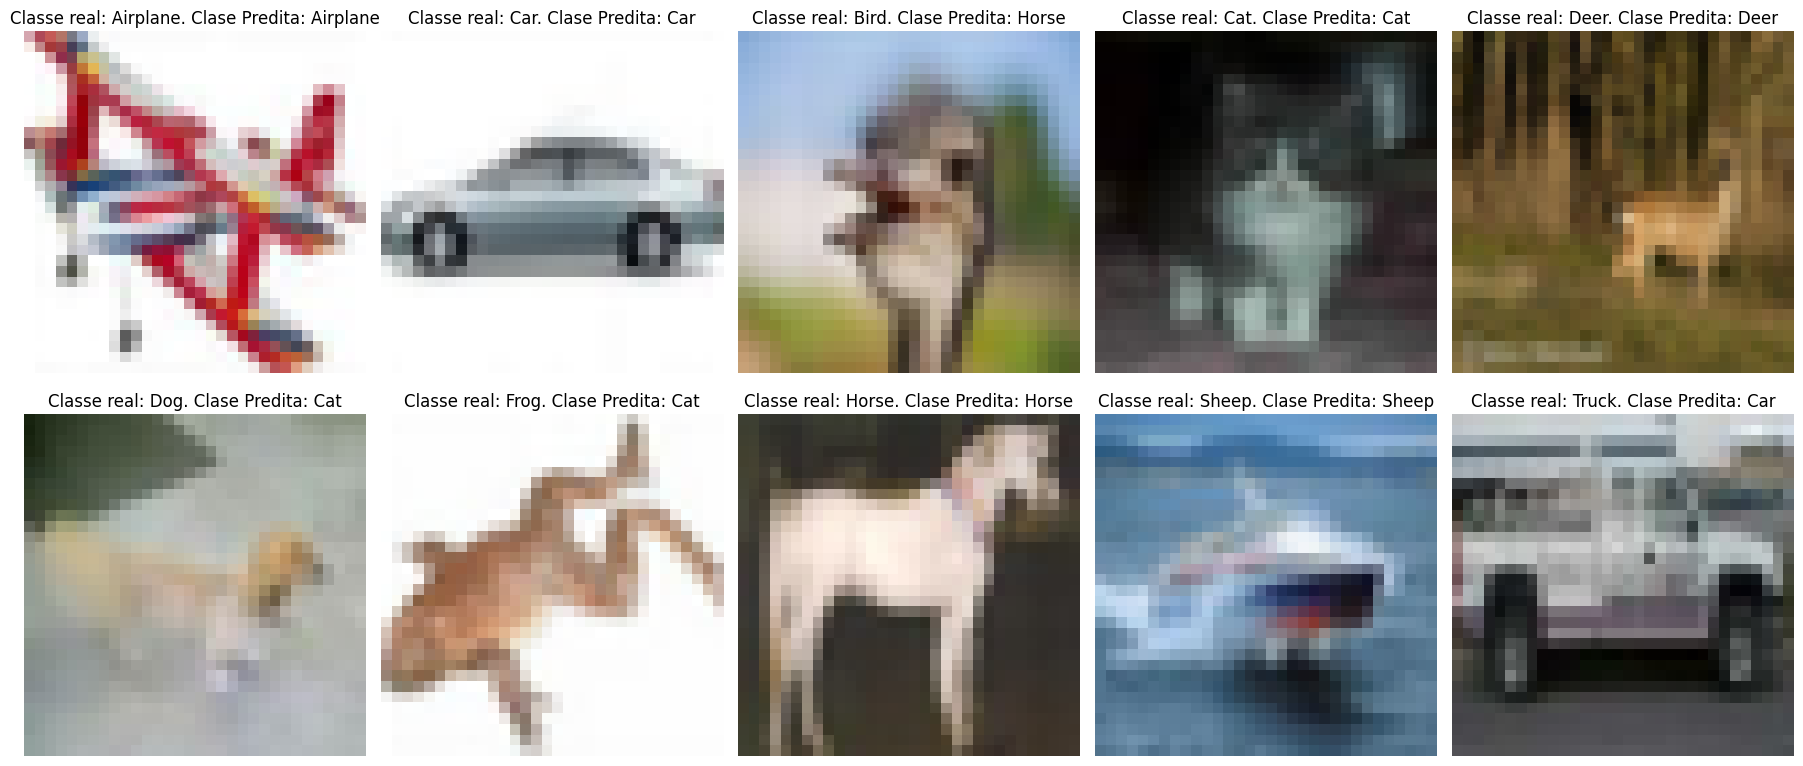

In [ ]:
# best model test
accuracy = trained_cnn3.evaluate(X_test, y_test, batch_size= 456)[1]
probas = trained_cnn3.predict(X_test, batch_size=456, verbose=False)
predictions = np.argmax(probas, axis=1)
conf_matrix = confusion_matrix(y_test, predictions)

print(f"Acurácia do modelo {"New CNN 3"}: {accuracy}")

print(f"Matriz de Confusão do Modelo: ")
print(conf_matrix)
cifar_cnn.test_prediction(trained_cnn3)